# Exploratory Data Analysis

In [17]:
import pandas as pd                                                    
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df =  pd.read_excel("../notebook/data/online_retail.xlsx")

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [21]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


checking for duplicate values

In [22]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


removing duplicate values

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df['Country'].value_counts()

Country
United Kingdom          490300
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [25]:
df[df['UnitPrice']<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [32]:
# Removing Negative/Invalid prices
df = df[df['UnitPrice']>0]

In [31]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Removing rows without any customer id

In [29]:
df.dropna(subset=['CustomerID'], inplace=True)
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [30]:
# converting customerdID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

In [33]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Quantity,401564.0,12.149911,-80995.0,2.0,5.0,12.0,80995.0,249.512649
InvoiceDate,401564,2011-07-10 12:06:07.514567936,2010-12-01 08:26:00,2011-04-06 15:02:00,2011-07-29 15:32:30,2011-10-20 11:58:00,2011-12-09 12:50:00,NaN
UnitPrice,401564.0,3.47441,0.001,1.25,1.95,3.75,38970.0,69.767501
CustomerID,401564.0,15281.266797,12346.0,13939.0,15145.0,16788.0,18287.0,1713.978947


In [35]:
# Flagging returns
df['is_return'] = df['Quantity']<0

df['Abs_quantity'] = df['Quantity'].abs()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return,Abs_quantity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,6
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6


In [44]:
df['revenue'] = round(df['Quantity'] * df['UnitPrice'],2)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return,Abs_quantity,revenue,month,day,year,week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,6,15.30,12,1,2010,48
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6,20.34,12,1,2010,48
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,8,22.00,12,1,2010,48
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6,20.34,12,1,2010,48
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6,20.34,12,1,2010,48


In [38]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Quantity,401564.0,12.149911,-80995.0,2.0,5.0,12.0,80995.0,249.512649
InvoiceDate,401564,2011-07-10 12:06:07.514567936,2010-12-01 08:26:00,2011-04-06 15:02:00,2011-07-29 15:32:30,2011-10-20 11:58:00,2011-12-09 12:50:00,NaN
UnitPrice,401564.0,3.47441,0.001,1.25,1.95,3.75,38970.0,69.767501
CustomerID,401564.0,15281.266797,12346.0,13939.0,15145.0,16788.0,18287.0,1713.978947
Abs_quantity,401564.0,13.509769,1.0,2.0,6.0,12.0,80995.0,249.442715
revenue,401564.0,20.615691,-168469.6,4.25,11.7,19.8,168469.6,430.373603


In [39]:
df['month'] = df['InvoiceDate'].dt.month
df['day'] = df['InvoiceDate'].dt.day
df['year'] = df['InvoiceDate'].dt.year
df['week'] = df['InvoiceDate'].dt.isocalendar().week
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return,Abs_quantity,revenue,month,day,year,week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,6,15.30,12,1,2010,48
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6,20.34,12,1,2010,48
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,8,22.00,12,1,2010,48
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6,20.34,12,1,2010,48
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,6,20.34,12,1,2010,48


In [40]:
df['week'].value_counts()

week
48    21293
49    20955
46    15974
47    14861
45    14494
44    13147
43    12248
40    12015
42    11601
38    10974
41    10833
39    10235
37     8682
36     8142
20     7749
19     7532
34     7430
29     7204
23     7202
50     7160
24     6808
33     6677
13     6594
31     6569
15     6559
12     6482
28     6384
30     6308
14     6284
25     6213
18     6174
11     6092
27     5917
21     5846
8      5816
4      5764
9      5651
32     5494
10     5489
1      5379
7      5274
5      5133
35     5088
16     4988
22     4875
26     4827
2      4749
3      4743
6      3983
17     3774
51     1899
Name: count, dtype: Int64

In [ ]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [ ]:
# Recency, Frequency, Monetary (RFM) features
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("revenue", "sum")
).reset_index()

rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346,326,2,0.00
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [46]:
rfm.shape

(4371, 4)

In [ ]:
# Monetary features
monetary_features = df.groupby("CustomerID").agg(
    TotalRevenue=("revenue", "sum"),
    AvgOrderValue=("revenue", lambda x: x.sum() / x.nunique()),
    MaxInvoiceValue=("revenue", "max"),
    MedianInvoiceValue=("revenue", "median")
).reset_index()
monetary_features.head()

,CustomerID,TotalRevenue,AvgOrderValue,MaxInvoiceValue,MedianInvoiceValue
0,12346,0.00,0.000000,77183.6,0.00
1,12347,4310.00,78.363636,249.6,17.00
2,12348,1797.24,112.327500,240.0,41.76
3,12349,1757.55,42.867073,300.0,17.70
4,12350,334.40,37.155556,40.0,19.80


In [49]:
monetary_features.shape

(4371, 5)

In [ ]:
# engagement based features
engagement_features = df.groupby("CustomerID").agg(
    TotalItems=("Abs_quantity", "sum"),
    AvgItemsPerOrder=("Abs_quantity", lambda x: x.sum() / x.nunique()),
    ProductDiversity=("StockCode", "nunique")
).reset_index()
engagement_features.head()

,CustomerID,TotalItems,AvgItemsPerOrder,ProductDiversity
0,12346,148430,148430.000000,1
1,12347,2458,163.866667,103
2,12348,2341,234.100000,22
3,12349,631,52.583333,73
4,12350,197,39.400000,17


In [52]:
engagement_features.shape

(4371, 4)

In [ ]:
# return features
returns = df.groupby("CustomerID").agg(
    ReturnedItems=("Abs_quantity", lambda x: x[df.loc[x.index, "is_return"]].sum()),
    TotalItems=("Abs_quantity", "sum"),
    ReturnInvoices=("InvoiceNo", lambda x: x[df.loc[x.index, "is_return"]].nunique()),
    TotalInvoices=("InvoiceNo", "nunique")
).reset_index()

returns["ReturnRate"] = returns["ReturnedItems"] / returns["TotalItems"]
returns["ReturnInvoiceRatio"] = returns["ReturnInvoices"] / returns["TotalInvoices"]
returns.head()

,CustomerID,ReturnedItems,TotalItems,ReturnInvoices,TotalInvoices,ReturnRate,ReturnInvoiceRatio
0,12346,74215,148430,1,2,0.5,0.5
1,12347,0,2458,0,7,0.0,0.0
2,12348,0,2341,0,4,0.0,0.0
3,12349,0,631,0,1,0.0,0.0
4,12350,0,197,0,1,0.0,0.0


In [54]:
returns.shape

(4371, 7)

In [ ]:
# Price-based features
price_features = df.groupby("CustomerID").agg(
    AvgUnitPrice=("UnitPrice", "mean"),
    PriceStdDev=("UnitPrice", "std")
).reset_index()
price_features.head()

,CustomerID,AvgUnitPrice,PriceStdDev
0,12346,1.040000,0.000000
1,12347,2.644011,2.255381
2,12348,5.764839,13.400323
3,12349,8.289041,35.028021
4,12350,3.841176,9.334751


In [62]:
price_features.shape

(4371, 3)

In [ ]:
# Time-based features
df["Hour"] = df["InvoiceDate"].dt.hour
df["IsWeekend"] = df["InvoiceDate"].dt.weekday >= 5
df["Month"] = df["InvoiceDate"].dt.to_period("M")

time_features = df.groupby("CustomerID").agg(
    PreferredHour=("Hour", lambda x: x.mode()[0]),
    WeekendRatio=("IsWeekend", "mean"),
    ActiveMonths=("Month", "nunique")
).reset_index()
time_features.head()

,CustomerID,PreferredHour,WeekendRatio,ActiveMonths
0,12346,10,0.000000,1
1,12347,14,0.000000,7
2,12348,19,0.096774,4
3,12349,9,0.000000,1
4,12350,16,0.000000,1


In [56]:
time_features.shape

(4371, 4)

In [ ]:
# Customer Lifetime features
lifetime = df.groupby("CustomerID").agg(
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max")
).reset_index()

lifetime["CustomerLifetimeDays"] = (
    lifetime["LastPurchase"] - lifetime["FirstPurchase"]
).dt.days
lifetime.head()

,CustomerID,FirstPurchase,LastPurchase,CustomerLifetimeDays
0,12346,2011-01-18 10:01:00,2011-01-18 10:17:00,0
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,365
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,282
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,0


In [58]:
lifetime.shape

(4371, 4)

In [ ]:
# geoghrpical features
geo = df.groupby("CustomerID").agg(
    Country=("Country", lambda x: x.mode()[0])
).reset_index()
geo.head()

,CustomerID,Country
0,12346,United Kingdom
1,12347,Iceland
2,12348,Finland
3,12349,Italy
4,12350,Norway


In [ ]:
# Merging all features into a single DataFrame
customer_features = (
    rfm
    .merge(monetary_features, on="CustomerID", how="left")
    .merge(engagement_features, on="CustomerID", how="left")
    .merge(returns[["CustomerID", "ReturnRate", "ReturnInvoiceRatio"]], on="CustomerID", how="left")
    .merge(price_features, on="CustomerID", how="left")
    .merge(time_features, on="CustomerID", how="left")
    .merge(lifetime[["CustomerID", "CustomerLifetimeDays"]], on="CustomerID", how="left")
    .merge(geo, on="CustomerID", how="left")
)
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,TotalRevenue,AvgOrderValue,MaxInvoiceValue,MedianInvoiceValue,TotalItems,AvgItemsPerOrder,ProductDiversity,ReturnRate,ReturnInvoiceRatio,AvgUnitPrice,PriceStdDev,PreferredHour,WeekendRatio,ActiveMonths,CustomerLifetimeDays,Country
0,12346,326,2,0.00,0.00,0.000000,77183.6,0.00,148430,148430.000000,1,0.5,0.5,1.040000,0.000000,10,0.000000,1,0,United Kingdom
1,12347,2,7,4310.00,4310.00,78.363636,249.6,17.00,2458,163.866667,103,0.0,0.0,2.644011,2.255381,14,0.000000,7,365,Iceland
2,12348,75,4,1797.24,1797.24,112.327500,240.0,41.76,2341,234.100000,22,0.0,0.0,5.764839,13.400323,19,0.096774,4,282,Finland
3,12349,19,1,1757.55,1757.55,42.867073,300.0,17.70,631,52.583333,73,0.0,0.0,8.289041,35.028021,9,0.000000,1,0,Italy
4,12350,310,1,334.40,334.40,37.155556,40.0,19.80,197,39.400000,17,0.0,0.0,3.841176,9.334751,16,0.000000,1,0,Norway


In [65]:
customer_features.shape

(4371, 20)

In [67]:
customer_features.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
CustomerID,4371.0,15300.145276,1722.310262,12346.0000,13813.500000,15301.000000,16778.500000,18287.000000
Recency,4371.0,92.064974,100.770046,1.0000,17.000000,50.000000,143.000000,374.000000
Frequency,4371.0,5.075726,9.332529,1.0000,1.000000,3.000000,5.000000,248.000000
Monetary,4371.0,1893.964635,8219.586584,-4287.6300,291.940000,644.240000,1608.940000,279489.020000
TotalRevenue,4371.0,1893.964635,8219.586584,-4287.6300,291.940000,644.240000,1608.940000,279489.020000
AvgOrderValue,4371.0,51.867999,147.055595,-4287.6300,19.059000,31.317188,50.563237,3861.000000
MaxInvoiceValue,4371.0,185.221887,2881.611984,-4287.6300,31.800000,52.020000,102.000000,168469.600000
MedianInvoiceValue,4371.0,24.358547,133.852917,-4287.6300,8.320000,15.300000,17.700000,3861.000000
TotalItems,4371.0,1241.143217,5867.882640,1.0000,158.000000,378.000000,989.500000,197687.000000
AvgItemsPerOrder,4371.0,134.871040,2562.786699,1.0000,24.500000,44.428571,85.173203,148430.000000


In [66]:
customer_features.isna().sum()

CustomerID               0
Recency                  0
Frequency                0
Monetary                 0
TotalRevenue             0
AvgOrderValue            0
MaxInvoiceValue          0
MedianInvoiceValue       0
TotalItems               0
AvgItemsPerOrder         0
ProductDiversity         0
ReturnRate               0
ReturnInvoiceRatio       0
AvgUnitPrice             0
PriceStdDev             78
PreferredHour            0
WeekendRatio             0
ActiveMonths             0
CustomerLifetimeDays     0
Country                  0
dtype: int64

# Data Visualisation


Text(0, 0.5, 'Total Sales in lakhs')

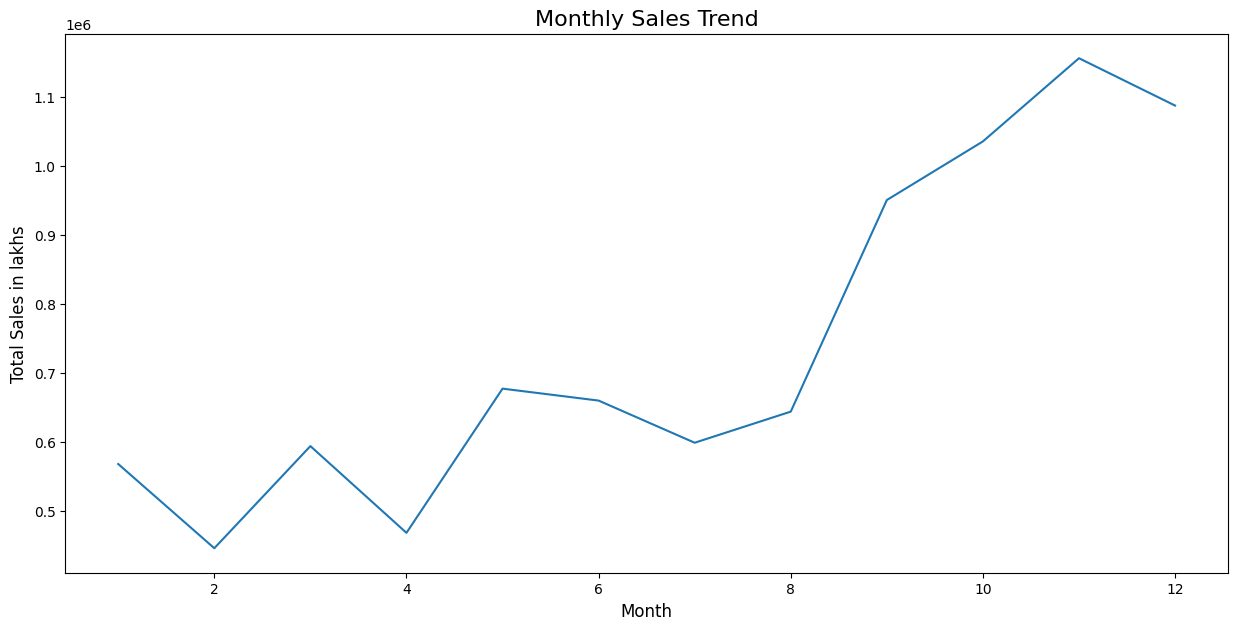

In [52]:
plt.figure(figsize=(15,7))
sns.lineplot(data=df, x='month', y='total_sales',errorbar=None,estimator='sum')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales in lakhs', fontsize=12)

Text(0, 0.5, 'Total Sales')

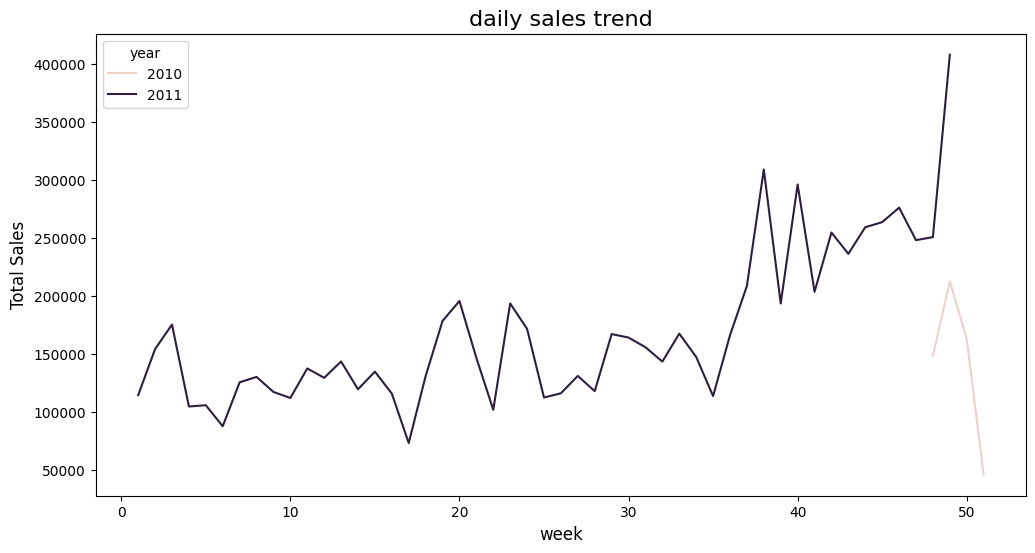

In [53]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='week',y='total_sales',errorbar=None,estimator='sum',hue='year')
plt.title('daily sales trend', fontsize=16)
plt.xlabel('week', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

In [62]:
country_sales = df.groupby('Country')['total_sales'].sum().reset_index()
country_sales = country_sales.sort_values(by='total_sales', ascending=False)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Netherlands'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Australia'),
  Text(6, 0, 'Spain'),
  Text(7, 0, 'Switzerland'),
  Text(8, 0, 'Belgium'),
  Text(9, 0, 'Sweden'),
  Text(10, 0, 'Japan'),
  Text(11, 0, 'Norway'),
  Text(12, 0, 'Portugal'),
  Text(13, 0, 'Finland'),
  Text(14, 0, 'Singapore'),
  Text(15, 0, 'Channel Islands'),
  Text(16, 0, 'Denmark'),
  Text(17, 0, 'Italy'),
  Text(18, 0, 'Cyprus'),
  Text(19, 0, 'Austria'),
  Text(20, 0, 'Poland'),
  Text(21, 0, 'Israel'),
  Text(22, 0, 'Greece'),
  Text(23, 0, 'Iceland'),
  Text(24, 0, 'Canada'),
  Text(25, 0, 'USA'),
  Text(26, 0, 'Malta'),
  Text(27, 0, 'Unspecified'),
  Text(28, 0, 'United Arab Emirates'),
  Text(29, 0, 'Lebano

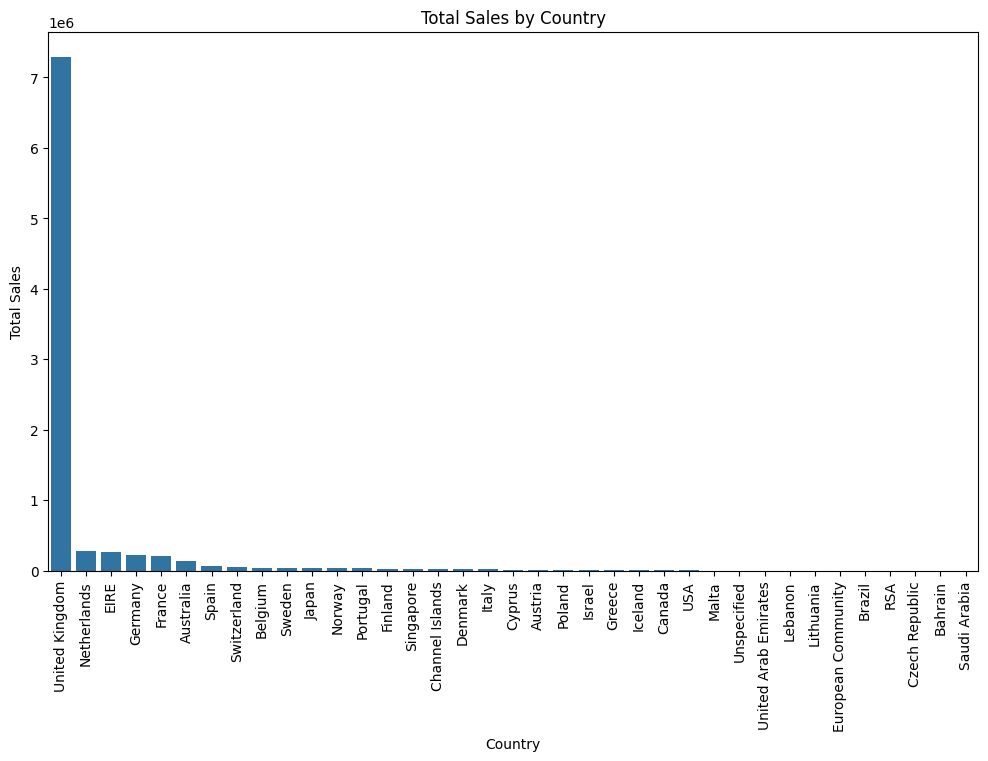

In [63]:
plt.figure(figsize=(12,7))
sns.barplot(data=country_sales, x='Country', y='total_sales', errorbar=None)
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.title('Total Sales by Country')
plt.xticks(rotation=90)

In [69]:
def add_value_labels(ax, spacing=5):
    """Add labels to the end of each bar in a bar chart.

    Arguments:
        ax (matplotlib.axes.Axes): The matplotlib object containing the axes of the plot to annotate.
        spacing (int): The distance between the labels and the bars.
    """
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)  # Format as integer since quantities are whole numbers
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va
        )

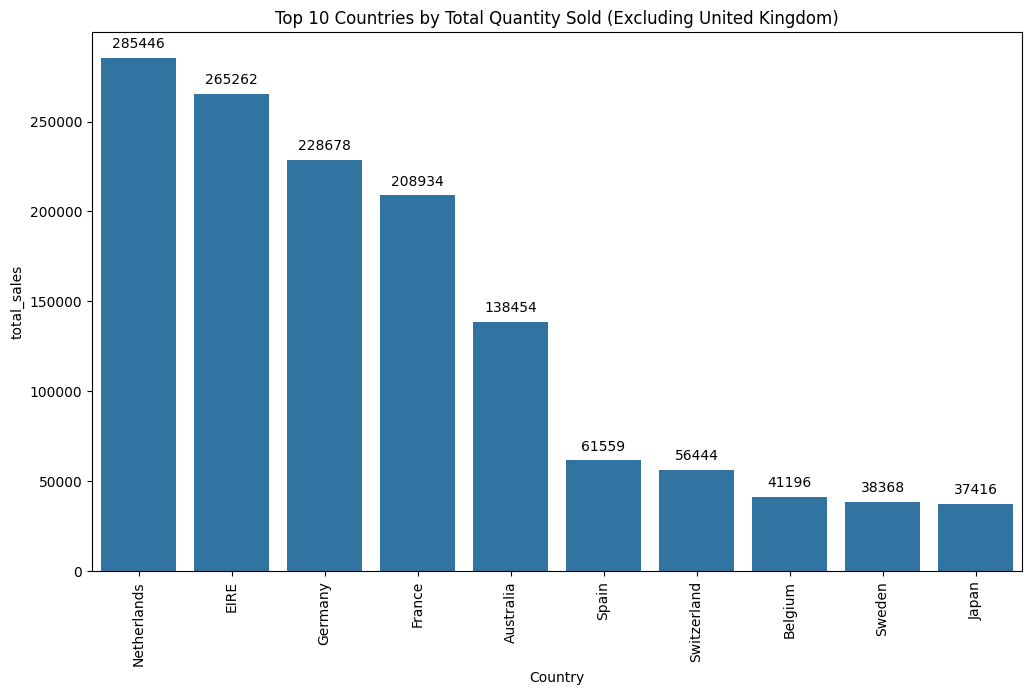

In [70]:
# Calculate total quantity per country, excluding United Kingdom
country_quantity = df[df['Country'] != 'United Kingdom'].groupby('Country')['total_sales'].sum().reset_index()

# Sort by total quantity descending and select top 10
top_10_countries = country_quantity.sort_values(by='total_sales', ascending=False).head(10)

# Plot the bar chart
plt.figure(figsize=(12,7))
plt1 = sns.barplot(data=top_10_countries, x='Country', y='total_sales', errorbar=None)
add_value_labels(plt1)
plt.xticks(rotation=90)
plt.title("Top 10 Countries by Total Quantity Sold (Excluding United Kingdom)")
plt.show()